# Supervised gate probe for the manual 1000-news dataset

This notebook checks whether the manual labels are learnable from text at all.

The LLM prompt-search notebook showed that the best local Gemma prompt improves the production prompt,
but still has weak factor recall. Here we train simple supervised text classifiers on the same manual labels
using 5-fold cross-validation. If a small TF-IDF model beats the LLM prompt, the practical conclusion is that
the production pipeline should not ask a small local LLM to choose from all 36 factors in one step. It needs a
supervised or retrieval candidate gate before the LLM scoring step.

In [1]:
from __future__ import annotations

import json
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

ROOT = Path.cwd()
if not (ROOT / "manage.py").exists():
    ROOT = Path(r"C:\Users\whynot\VSCodeProjects\news-zero-shot")
sys.path.insert(0, str(ROOT))

DATASET_PATH = ROOT / "interfax_news_manual_factor_dataset_1000.csv"
OUTPUT_DIR = ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
N_SPLITS = 5

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 180)

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

print(f"root={ROOT}")
print(f"dataset={DATASET_PATH}")
print(f"output_dir={OUTPUT_DIR}")

root=C:\Users\whynot\VSCodeProjects\news-zero-shot
dataset=C:\Users\whynot\VSCodeProjects\news-zero-shot\interfax_news_manual_factor_dataset_1000.csv
output_dir=C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs


## 1. Load labels

In [2]:
from analyzer.constants import normalize_factor_key
from analyzer.factors import FACTOR_CONFIG

raw_df = pd.read_csv(DATASET_PATH)

# The manual CSV is stable by position even if display encoding changes.
COL_ROW_ID = raw_df.columns[0]
COL_TITLE = raw_df.columns[9]
COL_DESCRIPTION = raw_df.columns[10]
COL_FIRST_PARAGRAPH = raw_df.columns[11]
COL_FULL_TEXT = raw_df.columns[12]
COL_APPLICABLE = raw_df.columns[35]
COL_PRIMARY_FACTOR = raw_df.columns[36]

FACTOR_KEYS = [item["key"] for item in FACTOR_CONFIG]
CLASS_LABELS = ["not_relevant"] + FACTOR_KEYS

def clean_text(value) -> str:
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()

def yes_no(value) -> bool:
    return str(value).strip().lower() in {"\u0434\u0430", "yes", "true", "1", "y"}

df = raw_df.copy()
df["dataset_row_id"] = pd.to_numeric(df[COL_ROW_ID], errors="raise").astype(int)
df["manual_applicable_bool"] = df[COL_APPLICABLE].map(yes_no)
df["manual_primary_factor"] = (
    df[COL_PRIMARY_FACTOR]
    .map(lambda value: normalize_factor_key(str(value).strip()) if pd.notna(value) else None)
    .fillna("not_relevant")
)
df["manual_primary_class"] = np.where(
    df["manual_applicable_bool"],
    df["manual_primary_factor"],
    "not_relevant",
)
df["eval_text"] = (
    df[COL_TITLE].map(clean_text)
    + ". "
    + df[COL_DESCRIPTION].map(clean_text)
    + ". "
    + df[COL_FIRST_PARAGRAPH].map(clean_text)
    + ". "
    + df[COL_FULL_TEXT].map(clean_text)
).str.strip()

y = df["manual_primary_class"].to_numpy()
X = df["eval_text"].to_numpy()

support = df["manual_primary_class"].value_counts()
supported_labels = [label for label in CLASS_LABELS if support.get(label, 0) > 0]
head_labels = [label for label in supported_labels if support.get(label, 0) >= 25]

print(f"rows={len(df)}")
print(f"supported primary classes={len(supported_labels)} of {len(CLASS_LABELS)}")
display(support.rename("support").to_frame())

rows=1000
supported primary classes=21 of 37


,support
manual_primary_class,
not_relevant,275
crime_count,201
industrial_production_index,176
enterprises_count,133
consumer_price_index,54
air_pollution,28
mortality_rate,28
life_expectancy,26
international_inflow,25


## 2. Metrics and models

In [3]:
def evaluate_primary(y_true, y_pred, model_name: str) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    y_true_app = (y_true != "not_relevant").astype(int)
    y_pred_app = (y_pred != "not_relevant").astype(int)
    precision, recall, app_f1, _ = precision_recall_fscore_support(
        y_true_app,
        y_pred_app,
        average="binary",
        zero_division=0,
    )
    tn, fp, fn, tp = confusion_matrix(y_true_app, y_pred_app, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "model": model_name,
        "n_news": int(len(y_true)),
        "primary_class_supported_macro_f1": f1_score(
            y_true,
            y_pred,
            labels=supported_labels,
            average="macro",
            zero_division=0,
        ),
        "primary_class_macro_f1_all37": f1_score(
            y_true,
            y_pred,
            labels=CLASS_LABELS,
            average="macro",
            zero_division=0,
        ),
        "primary_class_head_macro_f1_support_ge_25": f1_score(
            y_true,
            y_pred,
            labels=head_labels,
            average="macro",
            zero_division=0,
        ),
        "primary_class_weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=CLASS_LABELS,
            average="weighted",
            zero_division=0,
        ),
        "primary_class_accuracy": accuracy_score(y_true, y_pred),
        "applicability_precision": precision,
        "applicability_recall_relevant": recall,
        "applicability_f1": app_f1,
        "applicability_specificity_not_relevant": specificity,
        "tp_relevant": int(tp),
        "fp_relevant": int(fp),
        "fn_relevant": int(fn),
        "tn_not_relevant": int(tn),
    }

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)

models = {
    "word_tfidf_linearsvc": Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=50_000,
                    sublinear_tf=True,
                ),
            ),
            ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_SEED, dual="auto")),
        ]
    ),
    "char_word_tfidf_linearsvc": Pipeline(
        [
            (
                "features",
                FeatureUnion(
                    [
                        (
                            "word",
                            TfidfVectorizer(
                                analyzer="word",
                                ngram_range=(1, 2),
                                min_df=2,
                                max_features=50_000,
                                sublinear_tf=True,
                            ),
                        ),
                        (
                            "char",
                            TfidfVectorizer(
                                analyzer="char_wb",
                                ngram_range=(3, 5),
                                min_df=2,
                                max_features=50_000,
                                sublinear_tf=True,
                            ),
                        ),
                    ]
                ),
            ),
            ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_SEED, dual="auto")),
        ]
    ),
    "word_tfidf_logreg": Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    min_df=2,
                    max_features=50_000,
                    sublinear_tf=True,
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    max_iter=2_000,
                    class_weight="balanced",
                    C=2.0,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    ),
}

## 3. 5-fold cross-validation

In [4]:
rows = []
predictions = pd.DataFrame(
    {
        "dataset_row_id": df["dataset_row_id"],
        "manual_primary_class": y,
        "manual_applicable_bool": df["manual_applicable_bool"].astype(bool),
    }
)

for model_name, model in models.items():
    print(f"running {model_name}")
    pred = cross_val_predict(model, X, y, cv=cv, n_jobs=None)
    predictions[f"pred_{model_name}"] = pred
    rows.append(evaluate_primary(y, pred, model_name))

supervised_results = pd.DataFrame(rows).sort_values("primary_class_supported_macro_f1", ascending=False)
display(supervised_results.round(4))

running word_tfidf_linearsvc


C:\Users\whynot\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


running char_word_tfidf_linearsvc


C:\Users\whynot\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


running word_tfidf_logreg


C:\Users\whynot\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,model,n_news,primary_class_supported_macro_f1,primary_class_macro_f1_all37,primary_class_head_macro_f1_support_ge_25,primary_class_weighted_f1,primary_class_accuracy,applicability_precision,applicability_recall_relevant,applicability_f1,applicability_specificity_not_relevant,tp_relevant,fp_relevant,fn_relevant,tn_not_relevant
1,char_word_tfidf_linearsvc,1000,0.3175,0.1802,0.6094,0.6154,0.627,0.8569,0.8510,0.8540,0.6255,617,103,108,172
0,word_tfidf_linearsvc,1000,0.3125,0.1774,0.6005,0.5979,0.609,0.8446,0.8469,0.8457,0.5891,614,113,111,162
2,word_tfidf_logreg,1000,0.2872,0.1630,0.5695,0.5797,0.596,0.8340,0.8455,0.8397,0.5564,613,122,112,153


## 4. Compare with the best LLM prompt

,model,primary_class_supported_macro_f1,primary_class_macro_f1_all37,primary_class_head_macro_f1_support_ge_25,primary_class_weighted_f1,primary_class_accuracy,applicability_precision,applicability_recall_relevant,applicability_specificity_not_relevant
0,llm_best_balanced_recall_v2,0.2204,0.1251,0.3639,0.4488,NaN,0.8696,0.5793,0.7709
1,char_word_tfidf_linearsvc,0.3175,0.1802,0.6094,0.6154,0.627,0.8569,0.8510,0.6255
2,word_tfidf_linearsvc,0.3125,0.1774,0.6005,0.5979,0.609,0.8446,0.8469,0.5891
3,word_tfidf_logreg,0.2872,0.1630,0.5695,0.5797,0.596,0.8340,0.8455,0.5564


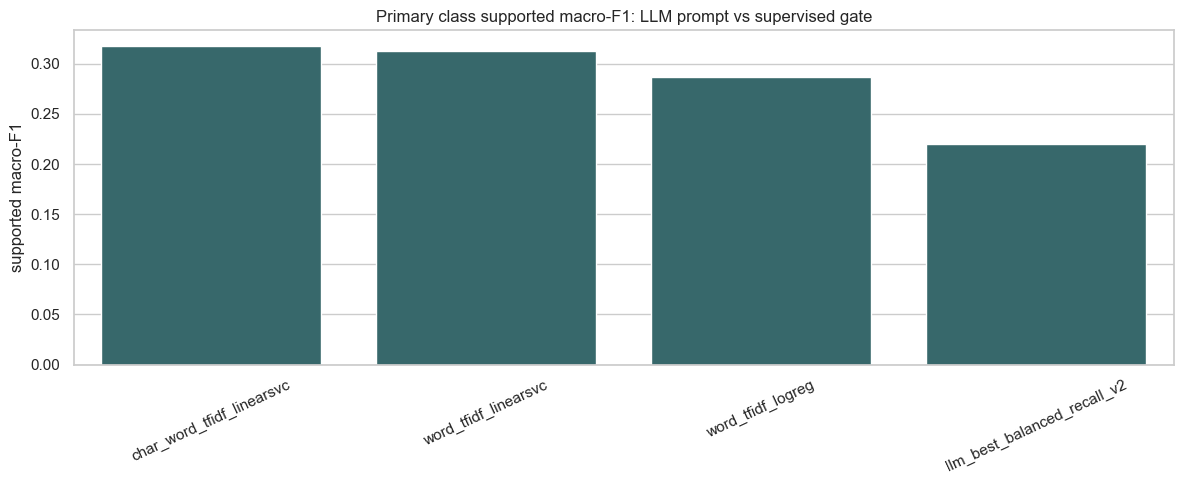

In [5]:
prompt_summary_path = OUTPUT_DIR / "manual_dataset_prompt_search_summary.json"
comparison_rows = []

if prompt_summary_path.exists():
    prompt_summary = json.loads(prompt_summary_path.read_text(encoding="utf-8"))
    comparison_rows.append(
        {
            "model": f"llm_best_{prompt_summary['full_best_variant']}",
            "n_news": prompt_summary["full_size"],
            "primary_class_supported_macro_f1": prompt_summary["full_best_main_primary_class_supported_macro_f1"],
            "primary_class_macro_f1_all37": prompt_summary["full_best_primary_class_macro_f1_all37"],
            "primary_class_head_macro_f1_support_ge_25": prompt_summary["full_best_primary_class_head_macro_f1_support_ge_25"],
            "primary_class_weighted_f1": prompt_summary["full_best_primary_class_weighted_f1"],
            "applicability_precision": prompt_summary["full_best_applicability_precision"],
            "applicability_recall_relevant": prompt_summary["full_best_applicability_recall_relevant"],
            "applicability_specificity_not_relevant": prompt_summary["full_best_applicability_specificity_not_relevant"],
        }
    )

comparison = pd.concat([pd.DataFrame(comparison_rows), supervised_results], ignore_index=True, sort=False)
display(
    comparison[
        [
            "model",
            "primary_class_supported_macro_f1",
            "primary_class_macro_f1_all37",
            "primary_class_head_macro_f1_support_ge_25",
            "primary_class_weighted_f1",
            "primary_class_accuracy",
            "applicability_precision",
            "applicability_recall_relevant",
            "applicability_specificity_not_relevant",
        ]
    ].round(4)
)

fig, ax = plt.subplots(figsize=(12, 5))
plot_df = comparison.sort_values("primary_class_supported_macro_f1", ascending=False)
sns.barplot(
    data=plot_df,
    x="model",
    y="primary_class_supported_macro_f1",
    ax=ax,
    color="#2f6f73",
)
ax.set_title("Primary class supported macro-F1: LLM prompt vs supervised gate")
ax.set_xlabel("")
ax.set_ylabel("supported macro-F1")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 5. Best supervised gate diagnostics

In [6]:
best_model_name = supervised_results.iloc[0]["model"]
best_pred = predictions[f"pred_{best_model_name}"]

report = pd.DataFrame(
    classification_report(
        y,
        best_pred,
        labels=CLASS_LABELS,
        output_dict=True,
        zero_division=0,
    )
).T

display(
    report.loc[supported_labels, ["precision", "recall", "f1-score", "support"]]
    .sort_values("support", ascending=False)
    .round(3)
)

errors = pd.DataFrame({"true": y, "pred": best_pred})
confusions = (
    errors[errors["true"] != errors["pred"]]
    .value_counts(["true", "pred"])
    .rename("count")
    .reset_index()
    .head(25)
)
display(confusions)

,precision,recall,f1-score,support
not_relevant,0.614,0.625,0.620,275.0
crime_count,0.655,0.726,0.689,201.0
industrial_production_index,0.667,0.636,0.651,176.0
enterprises_count,0.611,0.722,0.662,133.0
consumer_price_index,0.714,0.741,0.727,54.0
air_pollution,0.619,0.464,0.531,28.0
mortality_rate,0.400,0.500,0.444,28.0
life_expectancy,0.667,0.462,0.545,26.0
international_inflow,0.593,0.640,0.615,25.0
housing_area_per_capita,0.286,0.133,0.182,15.0


,true,pred,count
0,crime_count,not_relevant,32
1,industrial_production_index,not_relevant,29
2,not_relevant,enterprises_count,28
3,not_relevant,crime_count,27
4,not_relevant,industrial_production_index,27
5,enterprises_count,not_relevant,19
6,industrial_production_index,crime_count,12
7,industrial_production_index,enterprises_count,11
8,mortality_rate,crime_count,10
9,enterprises_count,crime_count,9


## 6. Save artifacts

In [7]:
results_path = OUTPUT_DIR / "manual_dataset_supervised_gate_results.csv"
predictions_path = OUTPUT_DIR / "manual_dataset_supervised_gate_predictions.csv"
report_path = OUTPUT_DIR / "manual_dataset_supervised_gate_best_class_report.csv"
summary_path = OUTPUT_DIR / "manual_dataset_supervised_gate_summary.json"

supervised_results.to_csv(results_path, index=False, encoding="utf-8")
predictions.to_csv(predictions_path, index=False, encoding="utf-8")
report.to_csv(report_path, encoding="utf-8")

best_row = supervised_results.iloc[0].to_dict()
summary = {
    "task": "supervised primary-class gate sanity check",
    "cv": f"{N_SPLITS}-fold StratifiedKFold",
    "best_model": best_model_name,
    "best_primary_class_supported_macro_f1": float(best_row["primary_class_supported_macro_f1"]),
    "best_primary_class_macro_f1_all37": float(best_row["primary_class_macro_f1_all37"]),
    "best_primary_class_head_macro_f1_support_ge_25": float(best_row["primary_class_head_macro_f1_support_ge_25"]),
    "best_primary_class_weighted_f1": float(best_row["primary_class_weighted_f1"]),
    "best_primary_class_accuracy": float(best_row["primary_class_accuracy"]),
    "best_applicability_precision": float(best_row["applicability_precision"]),
    "best_applicability_recall_relevant": float(best_row["applicability_recall_relevant"]),
    "best_applicability_specificity_not_relevant": float(best_row["applicability_specificity_not_relevant"]),
    "llm_prompt_search_summary": str(prompt_summary_path) if prompt_summary_path.exists() else None,
    "output_paths": {
        "results": str(results_path),
        "predictions": str(predictions_path),
        "best_class_report": str(report_path),
        "summary": str(summary_path),
    },
}
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

display(
    Markdown(
        f'''
        ## Conclusion

        Best supervised gate: `{best_model_name}`.

        Cross-val `primary_class_supported_macro_f1`: **{summary['best_primary_class_supported_macro_f1']:.3f}**.

        Cross-val strict `macro_f1_all37`: **{summary['best_primary_class_macro_f1_all37']:.3f}**.

        Cross-val head-class `macro_f1_support>=25`: **{summary['best_primary_class_head_macro_f1_support_ge_25']:.3f}**.

        Cross-val `weighted_f1`: **{summary['best_primary_class_weighted_f1']:.3f}**.

        Practical reading: the current LLM prompt is not enough as the first-stage classifier.
        The next production architecture should use a supervised/retrieval candidate gate and then ask the LLM
        to score only a small candidate set and sentiment/evidence.
        '''
    )
)

print("Saved artifacts:")
for key, value in summary["output_paths"].items():
    print(f"- {key}: {value}")


        ## Conclusion

        Best supervised gate: `char_word_tfidf_linearsvc`.

        Cross-val `primary_class_supported_macro_f1`: **0.317**.

        Cross-val strict `macro_f1_all37`: **0.180**.

        Cross-val head-class `macro_f1_support>=25`: **0.609**.

        Cross-val `weighted_f1`: **0.615**.

        Practical reading: the current LLM prompt is not enough as the first-stage classifier.
        The next production architecture should use a supervised/retrieval candidate gate and then ask the LLM
        to score only a small candidate set and sentiment/evidence.
        

Saved artifacts:
- results: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_supervised_gate_results.csv
- predictions: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_supervised_gate_predictions.csv
- best_class_report: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_supervised_gate_best_class_report.csv
- summary: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_supervised_gate_summary.json
